# 🏙️ ANALIZA E TË DHËNAVE - NYC Airbnb 2019

**Autor:** Data Science Team  
**Dataset:** New York City Airbnb Open Data 2019  
**Qëllimi:** Analiza eksplorative e tregut të Airbnb në NYC

---

## 📋 Përmbajtja

1. **Import i të Dhënave dhe Përgatitja**
2. **Analiza Gjeografike dhe Dendësia**
3. **Analiza e Çmimeve**
4. **Analiza e Korrelacioneve**
5. **Analiza e Tipeve të Dhomave**
6. **Analiza e Lagjeve**
7. **Analiza e Disponueshmërisë**
8. **Analiza e Aktivitetit**
9. **Analiza e Host-eve**
10. **Përfundime dhe Gjetje Kryesore**

---
## 1️⃣ IMPORT I TË DHËNAVE DHE PËRGATITJA

In [2]:
# Import i bibliotekave të nevojshme
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Konfigurimi i stilit të grafikëve
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Konfigurimi i madhësisë së default për grafikë
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [3]:
# Leximi i të dhënave
K = pd.read_csv("../data/cleaned_airbnb.csv")

print("=" * 70)
print("📊 INFORMACIONE TË PËRGJITHSHME MBI DATASET-IN")
print("=" * 70)
print(f"\nNumri total i listingjeve: {len(K):,}")
print(f"Numri i kolonave: {len(K.columns)}")
print(f"\nPërmasa e dataset-it: {K.shape}")
print(f"\nTipet e të dhënave:\n{K.dtypes}")

📊 INFORMACIONE TË PËRGJITHSHME MBI DATASET-IN

Numri total i listingjeve: 45,876
Numri i kolonave: 16

Përmasa e dataset-it: (45876, 16)

Tipet e të dhënave:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
days_since_last_review            float64
dtype: object


In [4]:
# Paraqitja e rreshtave të parë
K.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,438.0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,224.0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.72,1,365,3200.0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,179.0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,407.0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129,192.0
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,0.40,1,0,817.0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,3.47,1,220,190.0
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,0.99,1,0,893.0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,1.33,4,188,205.0


In [5]:
# Statistika përshkruese
K.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review
count,4.587600e+04,4.587600e+04,45876.000000,45876.000000,45876.000000,45876.000000,45876.000000,45876.000000,45876.000000,45876.000000,45876.000000
mean,1.890427e+07,6.633887e+07,40.728483,-73.950740,119.999673,6.940884,23.938748,1.249046,6.644411,109.400100,992.565721
std,1.092047e+07,7.757665e+07,0.055331,0.046477,68.128278,19.866529,45.315779,1.539239,31.023630,130.275539,1151.757590
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000,176.000000
25%,9.445256e+06,7.718759e+06,40.689230,-73.981940,65.000000,1.000000,1.000000,0.270000,1.000000,0.000000,195.000000
50%,1.952836e+07,3.028359e+07,40.721770,-73.954380,100.000000,2.000000,5.000000,0.720000,1.000000,39.000000,359.000000
75%,2.891654e+07,1.055746e+08,40.763390,-73.934330,159.000000,5.000000,24.000000,1.620000,2.000000,217.000000,1307.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,334.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,3200.000000


---
## 2️⃣ ANALIZA GJEOGRAFIKE DHE DENDËSIA E LISTINGJEVE

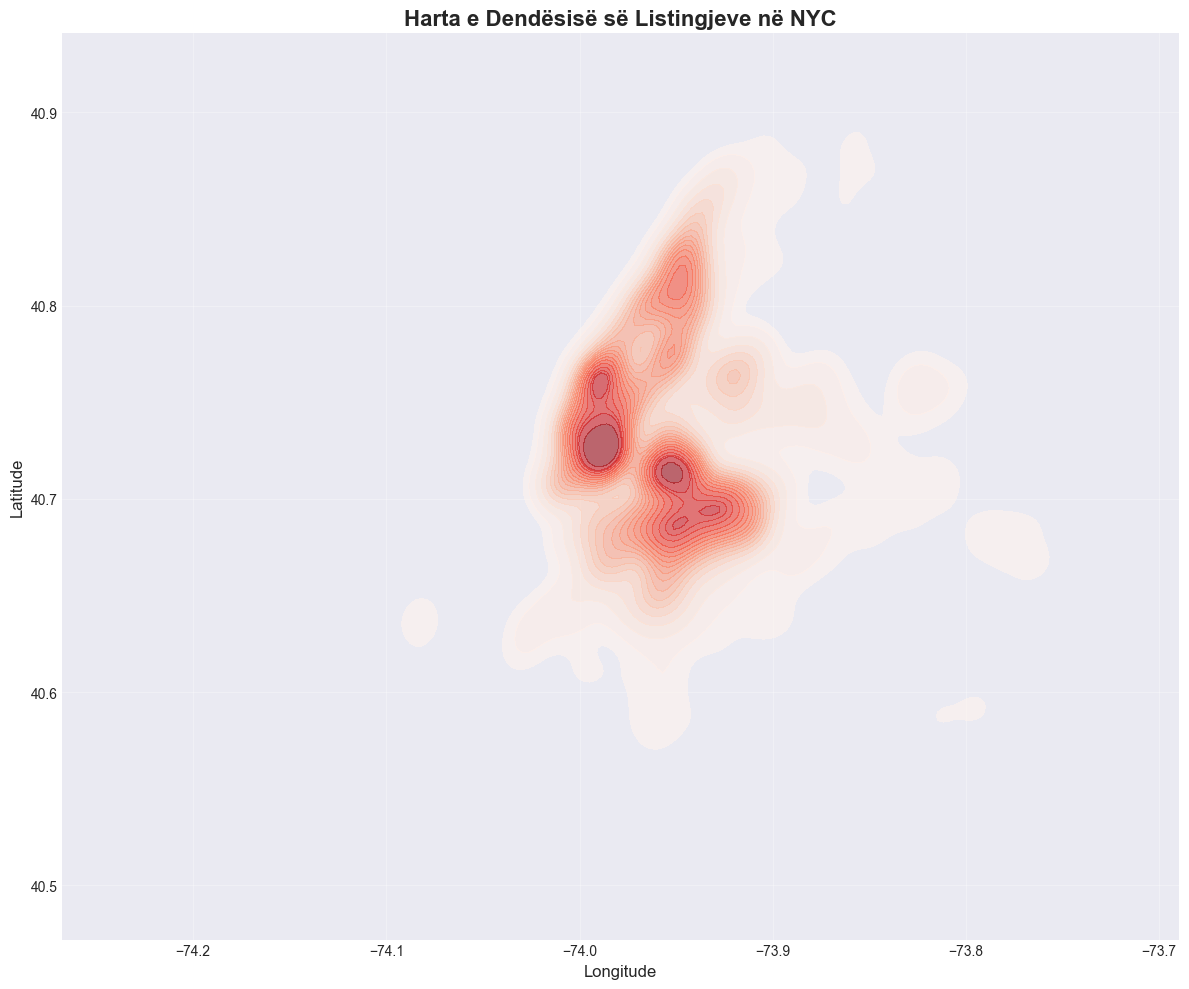


📊 INTERPRETIMI:
• Zonat më të kuqe tregojnë dendësi më të lartë të listingjeve
• Vërejmë koncentrim të lartë në Manhattan dhe pjesë të Brooklyn
• Zonat periferike kanë dendësi më të ulët


In [6]:
# 1. Density Map - Harta e dendësisë së listingjeve
plt.figure(figsize=(12, 10))

sns.kdeplot(
    x=K["longitude"],
    y=K["latitude"],
    fill=True,
    cmap="Reds",
    alpha=0.6,
    levels=20
)

plt.title("Harta e Dendësisë së Listingjeve në NYC", fontsize=16, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""\n📊 INTERPRETIMI:
• Zonat më të kuqe tregojnë dendësi më të lartë të listingjeve
• Vërejmë koncentrim të lartë në Manhattan dhe pjesë të Brooklyn
• Zonat periferike kanë dendësi më të ulët""")

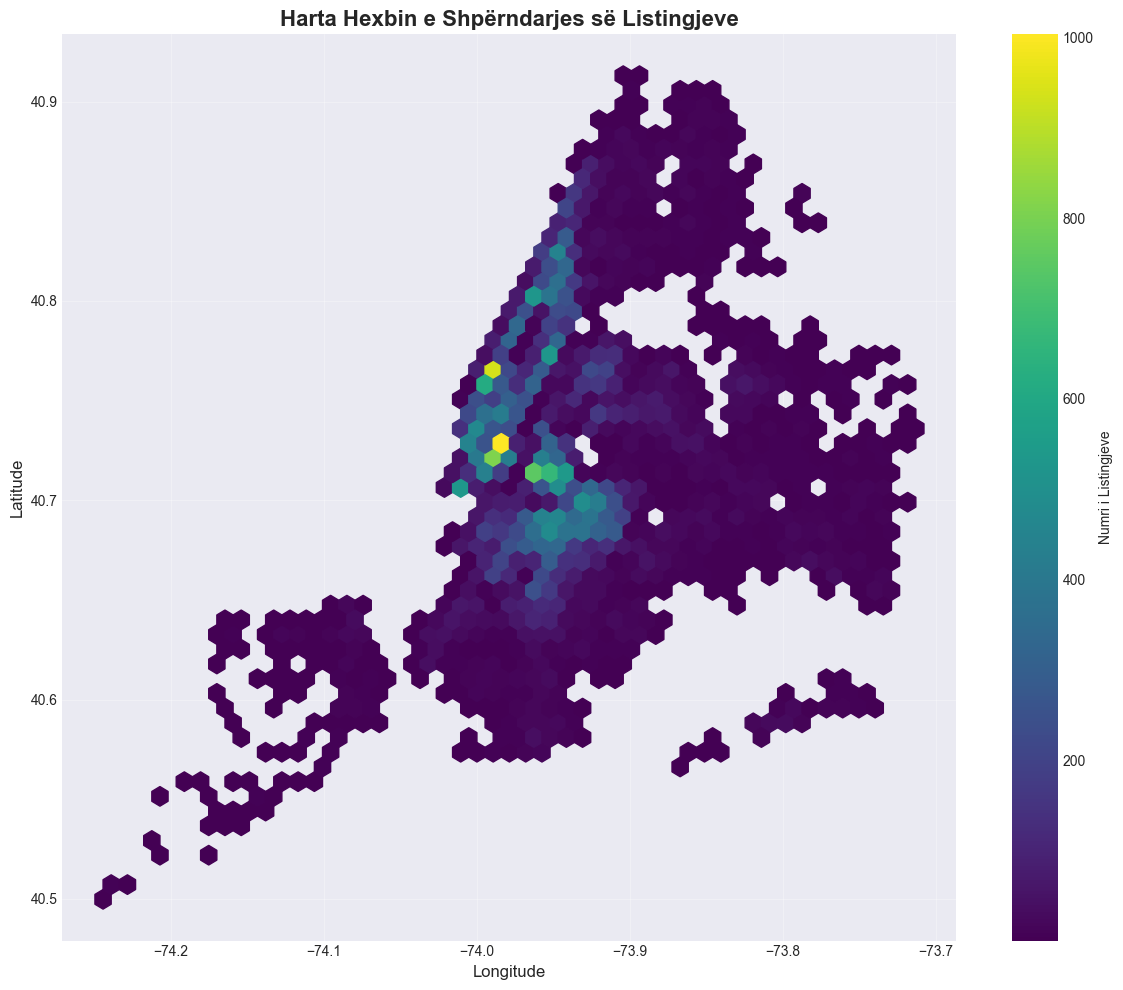

In [4]:
# 2. Hexbin Map - Paraqitje me gjashtëkëndësha
plt.figure(figsize=(12, 10))

hexbin = plt.hexbin(
    K["longitude"],
    K["latitude"],
    gridsize=50,
    cmap="viridis",
    mincnt=1
)

plt.colorbar(hexbin, label="Numri i Listingjeve")
plt.title("Harta Hexbin e Shpërndarjes së Listingjeve", fontsize=16, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

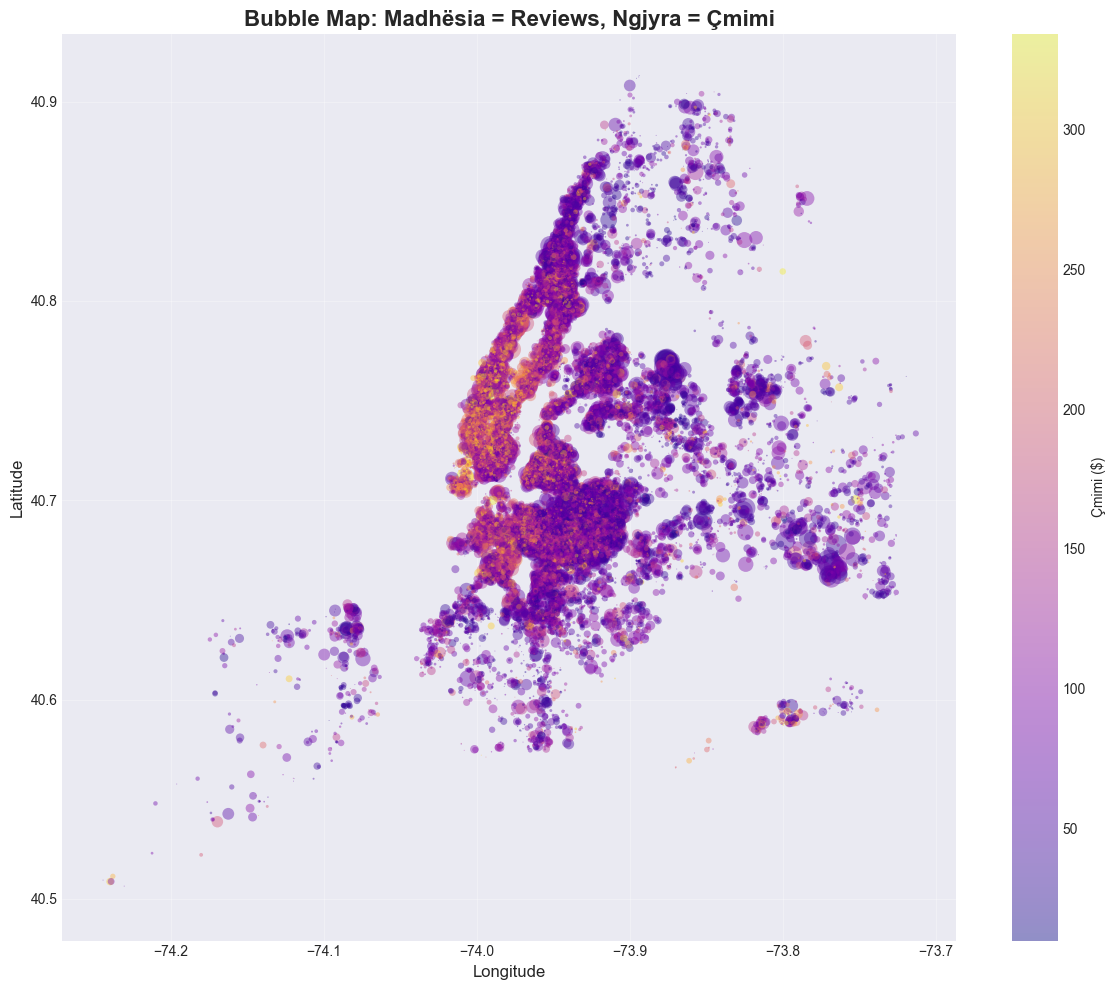


📊 INTERPRETIMI:
• Bubble më të mëdhenj = Më shumë reviews (më popullorë)
• Ngjyra më e nxehtë (e verdhë) = Çmime më të larta
• Manhattan ka tendencat e çmimeve më të larta


In [6]:
# 3. Bubble Map - Madhësia sipas numrit të reviews, ngjyra sipas çmimit
plt.figure(figsize=(12, 10))

scatter = plt.scatter(
    K["longitude"],
    K["latitude"],
    s=K["number_of_reviews"] * 0.5,
    c=K["price"],
    cmap="plasma",
    alpha=0.4,
    edgecolors='none'
)

plt.colorbar(scatter, label="Çmimi ($)")
plt.title("Bubble Map: Madhësia = Reviews, Ngjyra = Çmimi", fontsize=16, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""\n📊 INTERPRETIMI:
• Bubble më të mëdhenj = Më shumë reviews (më popullorë)
• Ngjyra më e nxehtë (e verdhë) = Çmime më të larta
• Manhattan ka tendencat e çmimeve më të larta""")

---
## 3️⃣ ANALIZA E ÇMIMEVE

In [7]:
# Statistika bazë të çmimeve
print("=" * 70)
print("💰 STATISTIKA E ÇMIMEVE")
print("=" * 70)
print(f"\nÇmimi mesatar: ${K['price'].mean():.2f}")
print(f"Çmimi median: ${K['price'].median():.2f}")
print(f"Çmimi minimal: ${K['price'].min():.2f}")
print(f"Çmimi maksimal: ${K['price'].max():.2f}")
print(f"Devijimi standard: ${K['price'].std():.2f}")
print(f"\nKuartilat:")
print(K['price'].describe())

💰 STATISTIKA E ÇMIMEVE

Çmimi mesatar: $120.00
Çmimi median: $100.00
Çmimi minimal: $10.00
Çmimi maksimal: $334.00
Devijimi standard: $68.13

Kuartilat:
count    45876.000000
mean       119.999673
std         68.128278
min         10.000000
25%         65.000000
50%        100.000000
75%        159.000000
max        334.000000
Name: price, dtype: float64


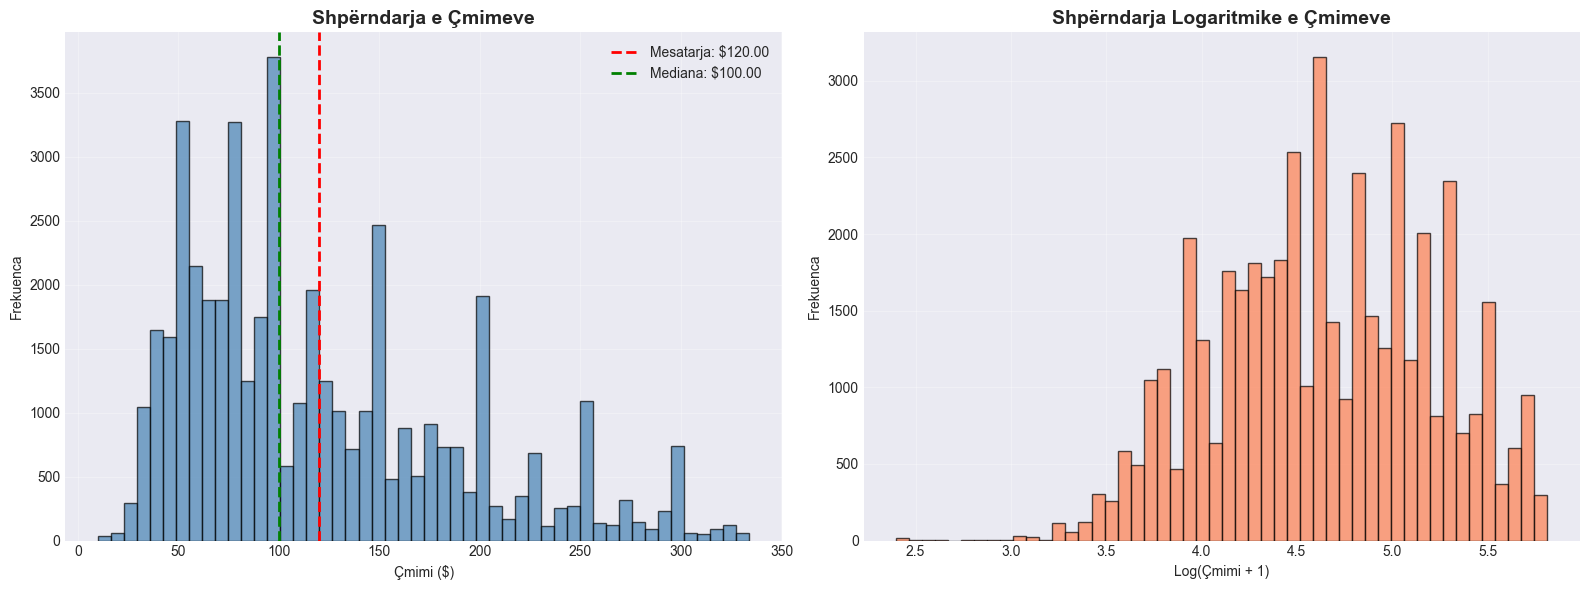


📊 INTERPRETIMI:
• Shpërndarja është e shtrembëruar djathtas (right-skewed)
• Shumica e listingjeve kanë çmime relativisht të ulëta
• Ekzistojnë outliers me çmime shumë të larta
• Transformimi logaritmik e bën shpërndarjen më normale


In [8]:
# Shpërndarja e çmimeve - Histogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram i çmimeve normale
axes[0].hist(K["price"], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(K['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mesatarja: ${K["price"].mean():.2f}')
axes[0].axvline(K['price'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${K["price"].median():.2f}')
axes[0].set_title("Shpërndarja e Çmimeve", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Çmimi ($)")
axes[0].set_ylabel("Frekuenca")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Histogram i çmimeve logaritmike
axes[1].hist(np.log1p(K["price"]), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title("Shpërndarja Logaritmike e Çmimeve", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Log(Çmimi + 1)")
axes[1].set_ylabel("Frekuenca")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""\n📊 INTERPRETIMI:
• Shpërndarja është e shtrembëruar djathtas (right-skewed)
• Shumica e listingjeve kanë çmime relativisht të ulëta
• Ekzistojnë outliers me çmime shumë të larta
• Transformimi logaritmik e bën shpërndarjen më normale""")

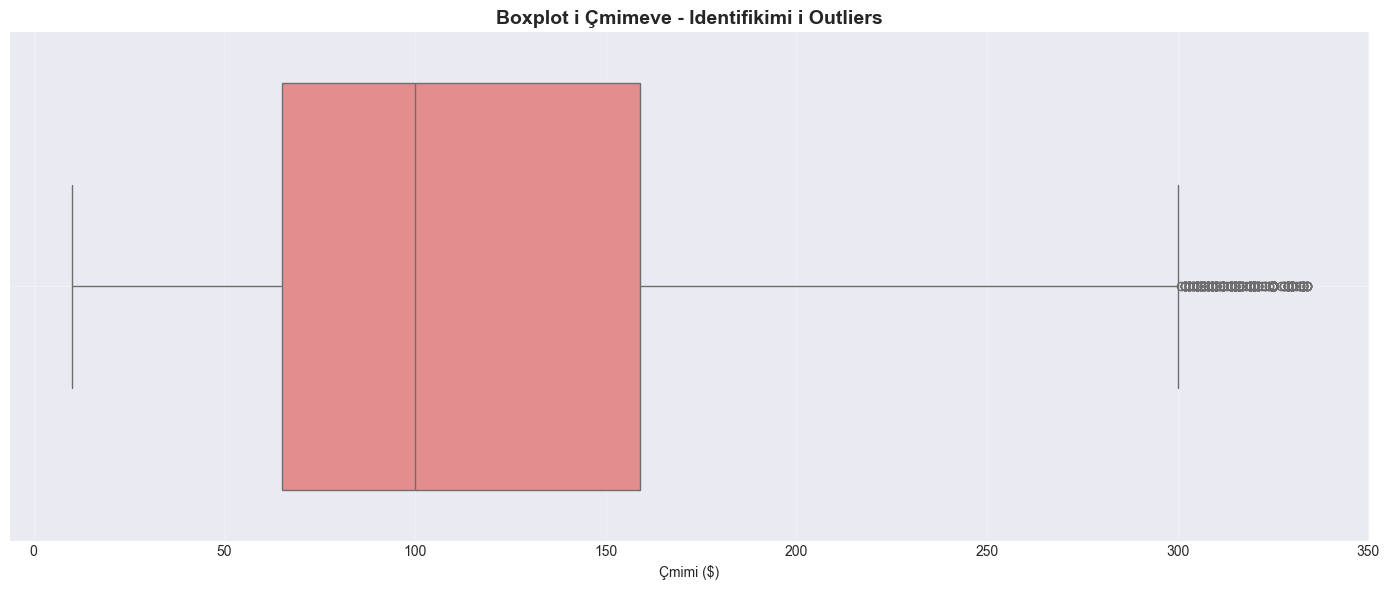


📊 OUTLIERS:
Numri i outliers: 384 (0.84%)
Kufiri i poshtëm: $-76.00
Kufiri i sipërm: $300.00


In [9]:
# Boxplot i çmimeve për të identifikuar outliers
plt.figure(figsize=(14, 6))

sns.boxplot(x=K["price"], color='lightcoral')
plt.title("Boxplot i Çmimeve - Identifikimi i Outliers", fontsize=14, fontweight='bold')
plt.xlabel("Çmimi ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Llogaritja e outliers
Q1 = K['price'].quantile(0.25)
Q3 = K['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = K[(K['price'] < Q1 - 1.5*IQR) | (K['price'] > Q3 + 1.5*IQR)]

print(f"\n📊 OUTLIERS:")
print(f"Numri i outliers: {len(outliers):,} ({len(outliers)/len(K)*100:.2f}%)")
print(f"Kufiri i poshtëm: ${Q1 - 1.5*IQR:.2f}")
print(f"Kufiri i sipërm: ${Q3 + 1.5*IQR:.2f}")

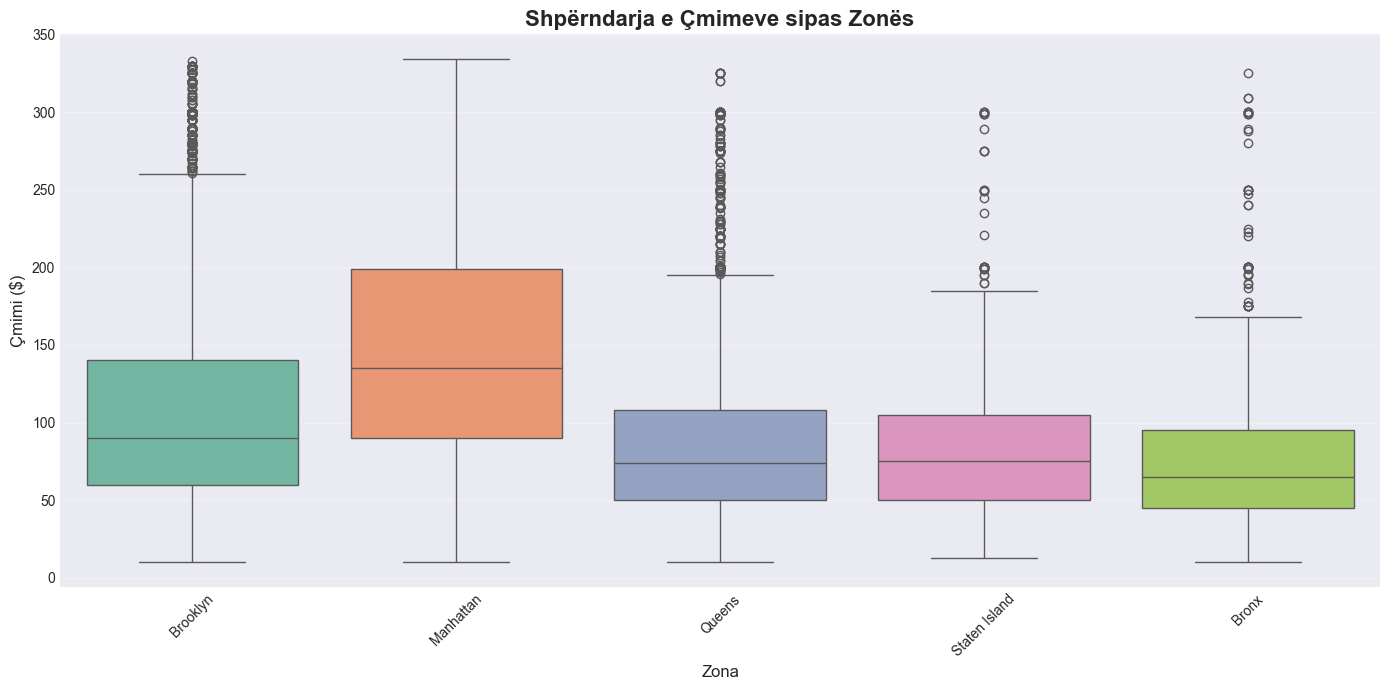


📊 STATISTIKA E ÇMIMEVE SIPAS ZONËS:

                       mean  median    std  min  max
neighbourhood_group                                 
Bronx                 77.39    65.0  47.09   10  325
Brooklyn             105.76    90.0  60.92   10  333
Manhattan            145.95   135.0  70.46   10  334
Queens                88.92    74.0  53.54   10  325
Staten Island         89.24    75.0  57.70   13  300


In [10]:
# Çmimet sipas zonës - Boxplot
plt.figure(figsize=(14, 7))

sns.boxplot(
    x="neighbourhood_group",
    y="price",
    data=K,
    palette="Set2"
)

plt.title("Shpërndarja e Çmimeve sipas Zonës", fontsize=16, fontweight='bold')
plt.xlabel("Zona", fontsize=12)
plt.ylabel("Çmimi ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistika sipas zonës
print("\n📊 STATISTIKA E ÇMIMEVE SIPAS ZONËS:\n")
zone_stats = K.groupby('neighbourhood_group')['price'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
print(zone_stats)

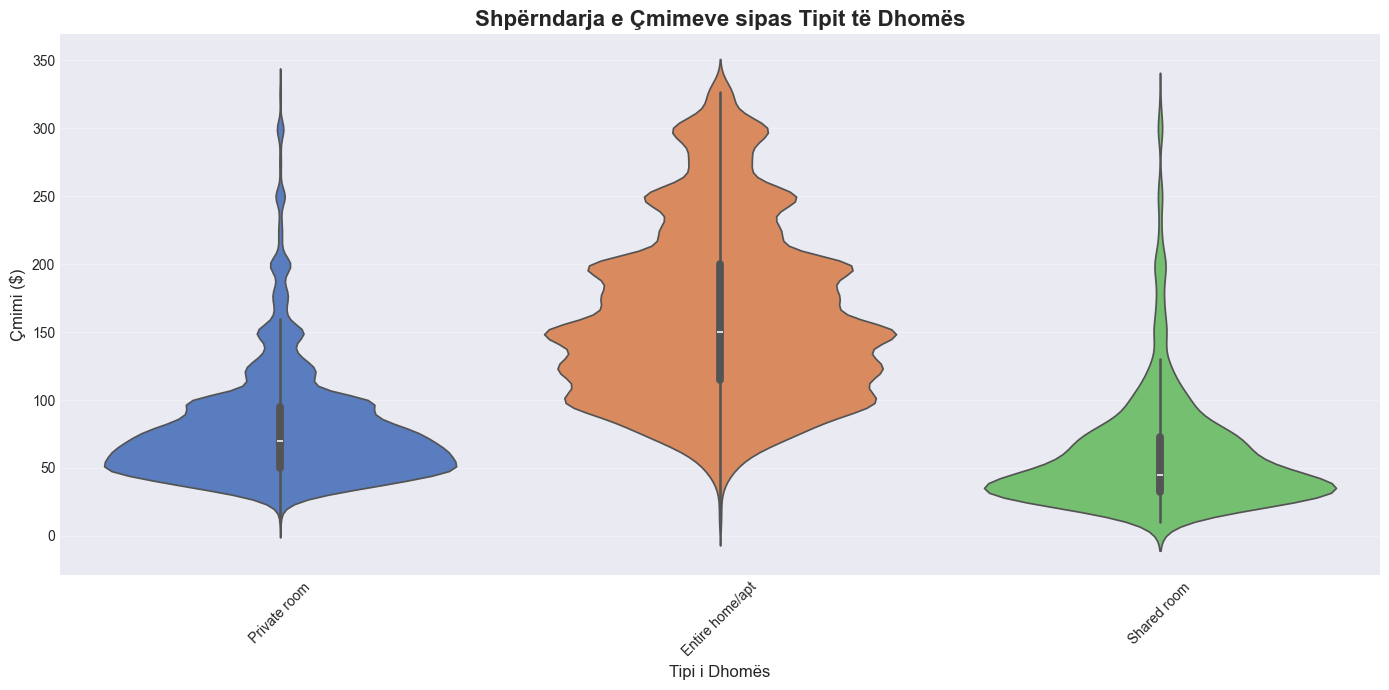


📊 STATISTIKA E ÇMIMEVE SIPAS TIPIT TË DHOMËS:

                   mean  median    std  count  percentage
room_type                                                
Entire home/apt  162.53   150.0  63.36  22772       49.64
Private room      79.05    70.0  41.16  21969       47.89
Shared room       59.34    45.0  42.76   1135        2.47


In [11]:
# Çmimet sipas tipit të dhomës - Violin Plot
plt.figure(figsize=(14, 7))

sns.violinplot(
    x="room_type",
    y="price",
    data=K,
    palette="muted"
)

plt.title("Shpërndarja e Çmimeve sipas Tipit të Dhomës", fontsize=16, fontweight='bold')
plt.xlabel("Tipi i Dhomës", fontsize=12)
plt.ylabel("Çmimi ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistika sipas tipit të dhomës
print("\n📊 STATISTIKA E ÇMIMEVE SIPAS TIPIT TË DHOMËS:\n")
room_stats = K.groupby('room_type')['price'].agg(['mean', 'median', 'std', 'count']).round(2)
room_stats['percentage'] = (room_stats['count'] / len(K) * 100).round(2)
print(room_stats)

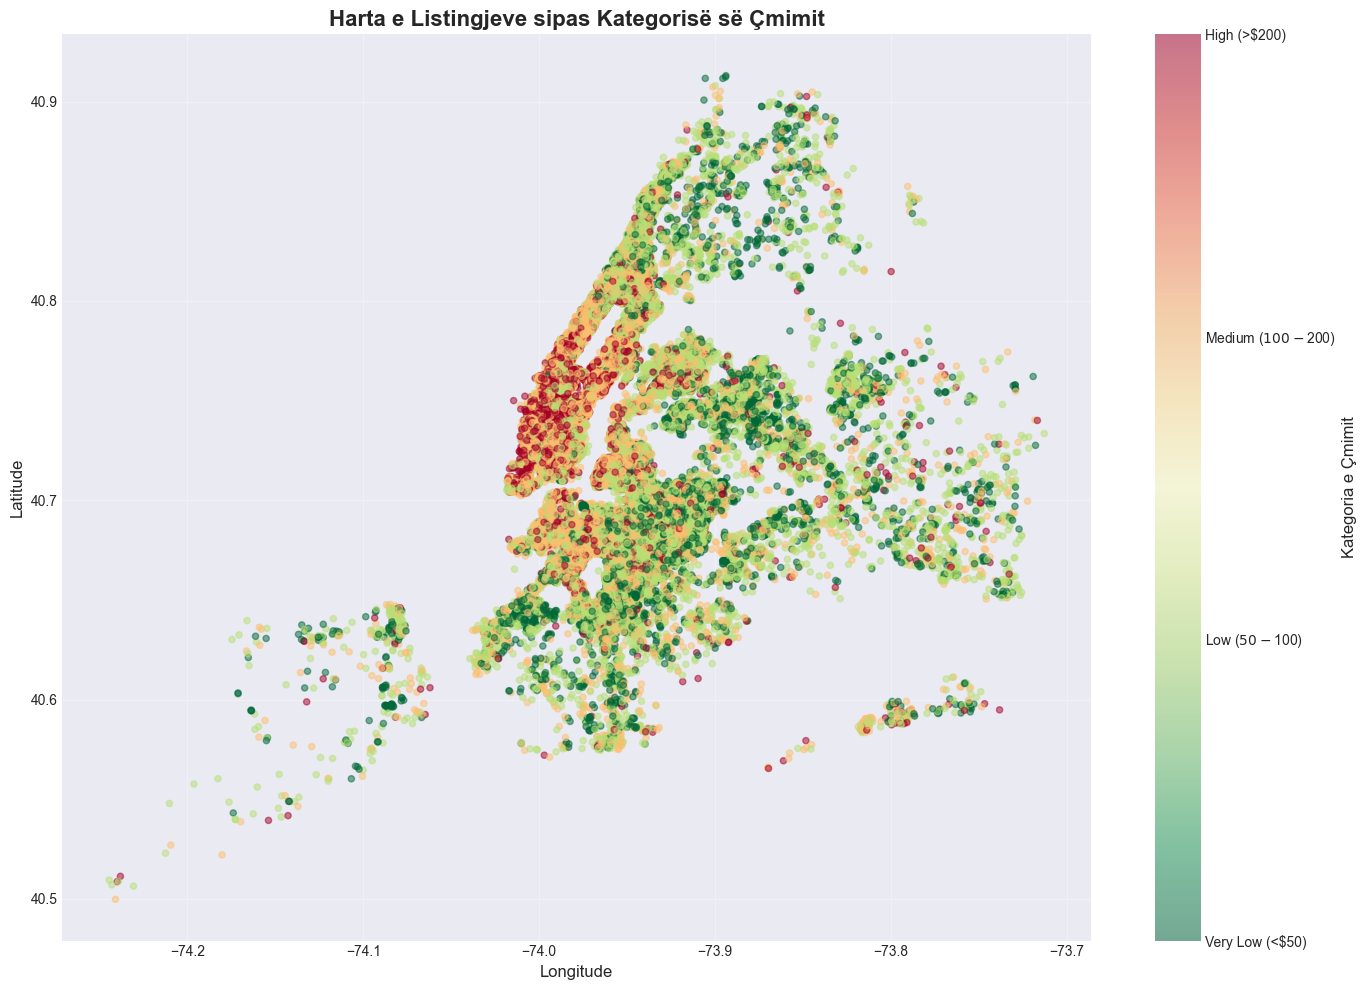


📊 SHPËRNDARJA E KATEGORIVE TË ÇMIMEVE:

   Very Low (<$50)            6,542 listingje ( 14.3%)
   Low ($50-$100)            17,356 listingje ( 37.8%)
   Medium ($100-$200)        16,571 listingje ( 36.1%)
   High (>$200)               5,407 listingje ( 11.8%)


In [12]:
# Kategorizimi i çmimeve
max_price = K["price"].max()

K["price_category"] = pd.cut(
    K["price"],
    bins=[0, 50, 100, 200, max_price],
    labels=["Very Low (<$50)", "Low ($50-$100)", "Medium ($100-$200)", "High (>$200)"],
    include_lowest=True
)

# Harta e kategorive të çmimeve
plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    K["longitude"],
    K["latitude"],
    c=K["price_category"].cat.codes,
    cmap="RdYlGn_r",
    alpha=0.5,
    s=20
)

plt.title("Harta e Listingjeve sipas Kategorisë së Çmimit", fontsize=16, fontweight='bold')
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

cbar = plt.colorbar(scatter, ticks=range(len(K["price_category"].cat.categories)))
cbar.set_ticklabels(K["price_category"].cat.categories)
cbar.set_label('Kategoria e Çmimit', fontsize=12)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Shpërndarja e kategorive
print("\n📊 SHPËRNDARJA E KATEGORIVE TË ÇMIMEVE:\n")
price_cat_dist = K['price_category'].value_counts().sort_index()
for cat, count in price_cat_dist.items():
    pct = (count / len(K)) * 100
    print(f"   {cat:<25} {count:>6,} listingje ({pct:>5.1f}%)")

---
## 4️⃣ ANALIZA E KORRELACIONEVE

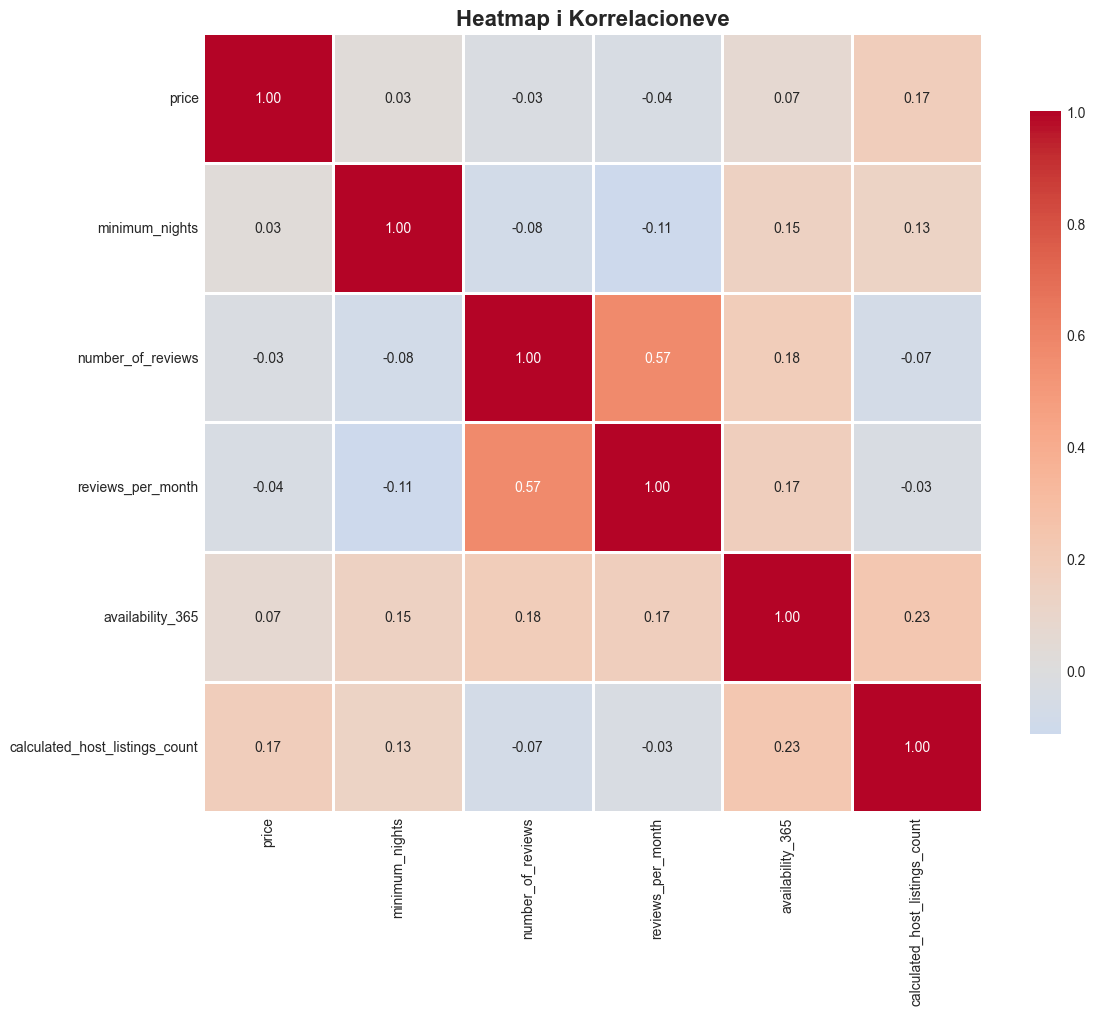


📊 INTERPRETIMI I KORRELACIONEVE:
• Korrelacione pozitive (të kuqe): Variablat rriten së bashku
• Korrelacione negative (të kaltërta): Njëri rritet kur tjetri zvogëlohet
• Vlera afër 0 (të bardha): Nuk ka korrelacion të fortë

📊 KORRELACIONET ME ÇMIMIN (të renditura):

   calculated_host_listings_count       0.174
   availability_365                     0.067
   minimum_nights                       0.031
   number_of_reviews                   -0.028
   reviews_per_month                   -0.040


In [13]:
# Heatmap i korrelacionit
plt.figure(figsize=(12, 10))

# Zgjedhja e variablave numerike
numeric_vars = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "availability_365",
    "calculated_host_listings_count"
]

correlation_matrix = K[numeric_vars].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap i Korrelacioneve", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("""\n📊 INTERPRETIMI I KORRELACIONEVE:
• Korrelacione pozitive (të kuqe): Variablat rriten së bashku
• Korrelacione negative (të kaltërta): Njëri rritet kur tjetri zvogëlohet
• Vlera afër 0 (të bardha): Nuk ka korrelacion të fortë""")

# Gjej korrelacionet më të forta me çmimin
print("\n📊 KORRELACIONET ME ÇMIMIN (të renditura):\n")
price_corr = correlation_matrix['price'].sort_values(ascending=False)
for var, corr in price_corr.items():
    if var != 'price':
        print(f"   {var:<35} {corr:>6.3f}")

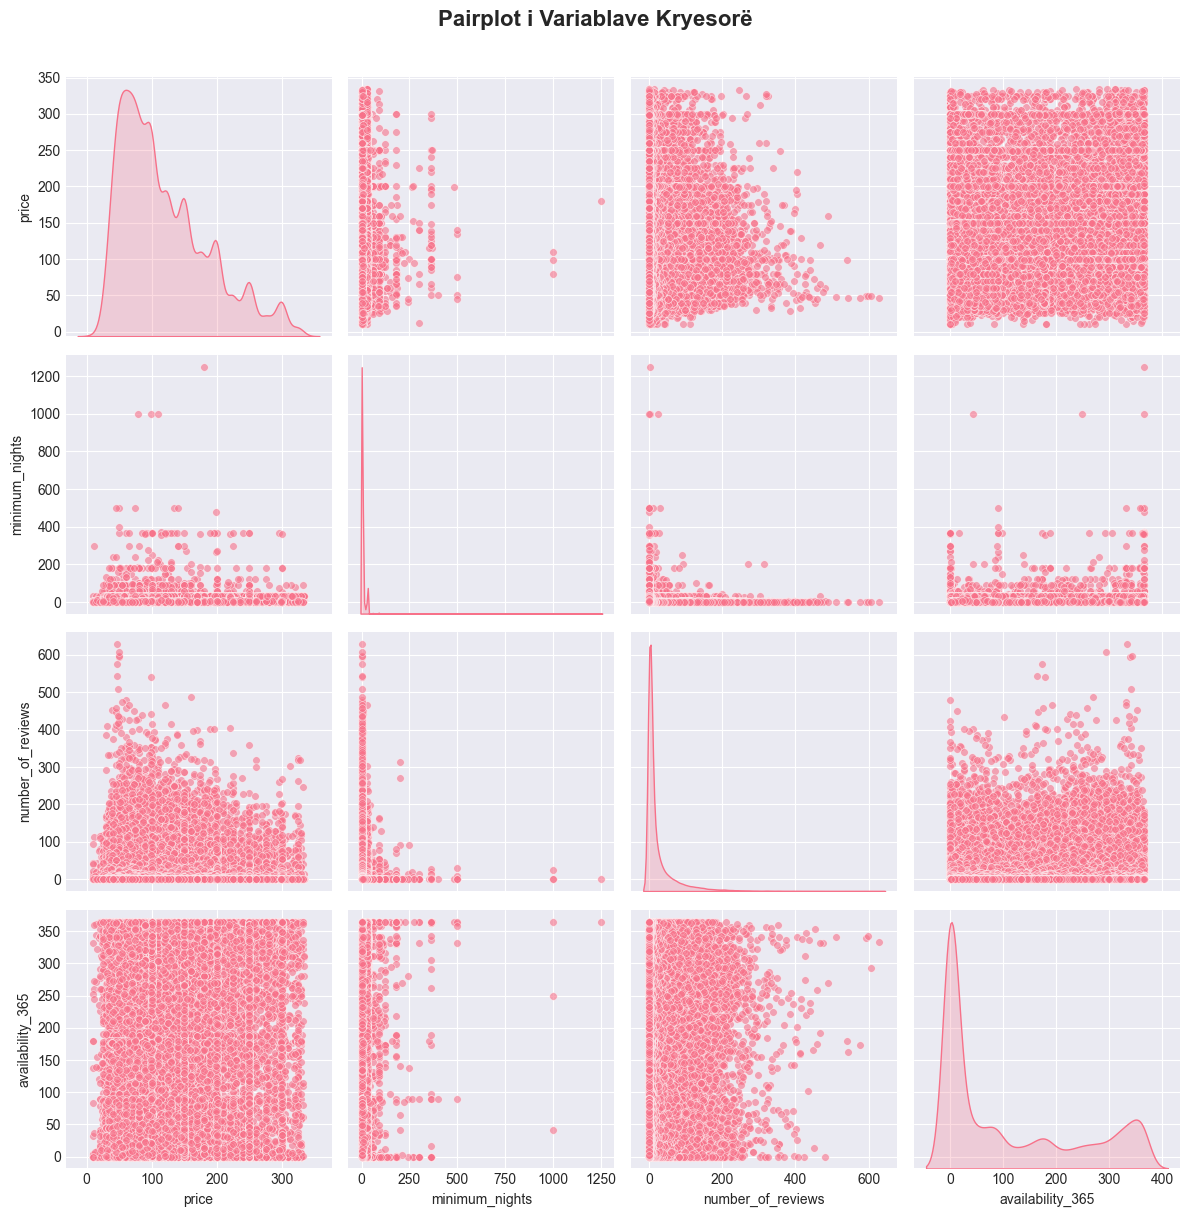

In [15]:
# Pairplot për të parë relacionet vizualisht
selected_vars = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "availability_365"
]

sns.pairplot(
    K[selected_vars],
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 30},
    height=3
)

plt.suptitle("Pairplot i Variablave Kryesorë", y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

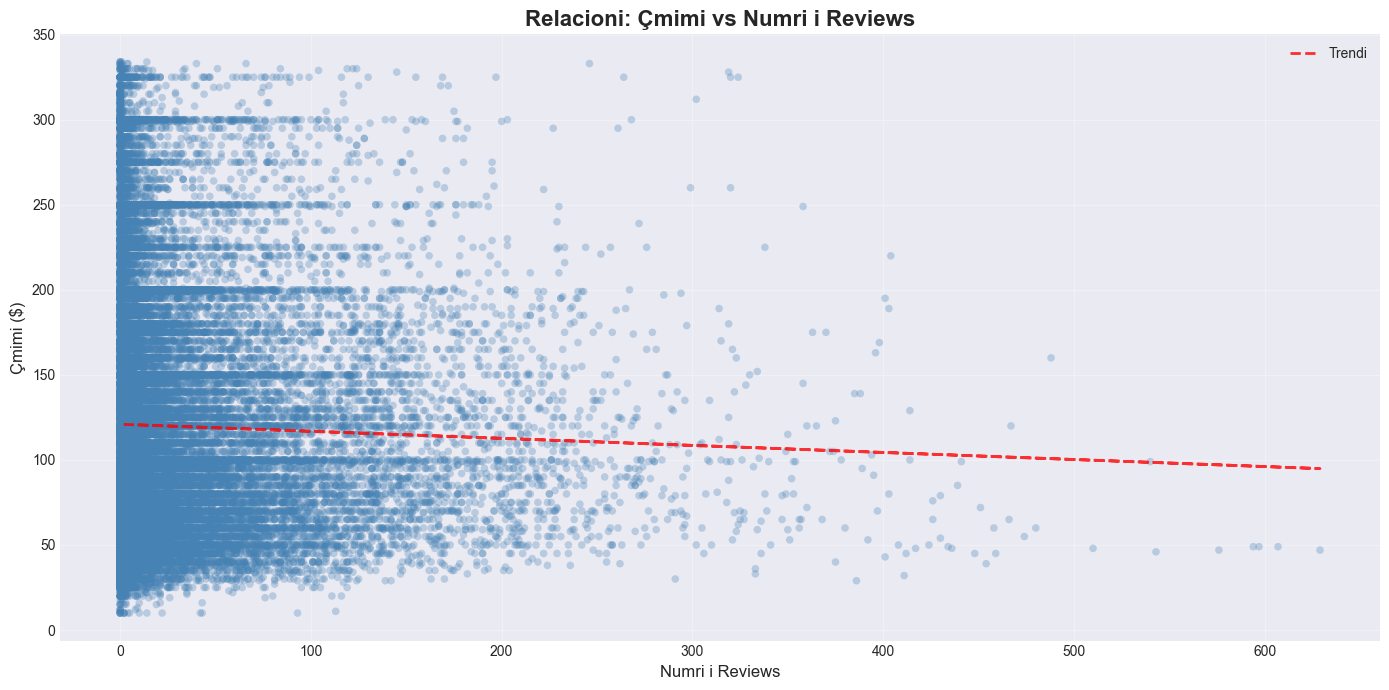


📊 Korrelacioni: -0.028


In [16]:
# Scatter plot: Çmimi vs Numri i Reviews
plt.figure(figsize=(14, 7))

plt.scatter(
    K["number_of_reviews"],
    K["price"],
    alpha=0.3,
    s=30,
    c='steelblue',
    edgecolors='none'
)

plt.title("Relacioni: Çmimi vs Numri i Reviews", fontsize=16, fontweight='bold')
plt.xlabel("Numri i Reviews", fontsize=12)
plt.ylabel("Çmimi ($)", fontsize=12)
plt.grid(alpha=0.3)

# Shto regression line
z = np.polyfit(K["number_of_reviews"], K["price"], 1)
p = np.poly1d(z)
plt.plot(K["number_of_reviews"], p(K["number_of_reviews"]), "r--", alpha=0.8, linewidth=2, label='Trendi')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 Korrelacioni: {K['price'].corr(K['number_of_reviews']):.3f}")

---
## 5️⃣ ANALIZA E TIPEVE TË DHOMAVE

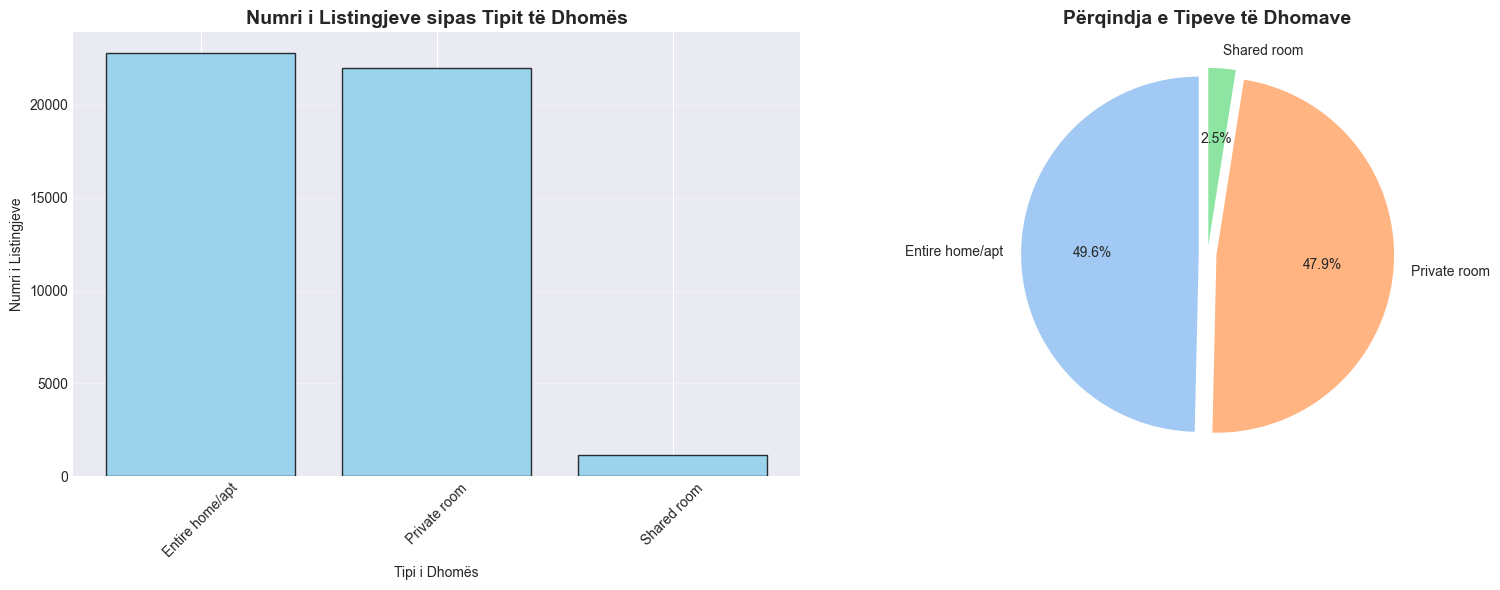


📊 SHPËRNDARJA E TIPEVE TË DHOMAVE:

   Entire home/apt           22,772 ( 49.6%)
   Private room              21,969 ( 47.9%)
   Shared room                1,135 (  2.5%)


In [17]:
# Shpërndarja e tipeve të dhomave
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count plot
room_counts = K['room_type'].value_counts()
axes[0].bar(room_counts.index, room_counts.values, color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_title("Numri i Listingjeve sipas Tipit të Dhomës", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Tipi i Dhomës")
axes[0].set_ylabel("Numri i Listingjeve")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# Pie chart
colors = sns.color_palette('pastel')[0:len(room_counts)]
axes[1].pie(
    room_counts.values,
    labels=room_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.05]*len(room_counts)
)
axes[1].set_title("Përqindja e Tipeve të Dhomave", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 SHPËRNDARJA E TIPEVE TË DHOMAVE:\n")
for room, count in room_counts.items():
    pct = (count / len(K)) * 100
    print(f"   {room:<25} {count:>6,} ({pct:>5.1f}%)")

---
## 6️⃣ ANALIZA E LAGJEVE (NEIGHBOURHOODS)

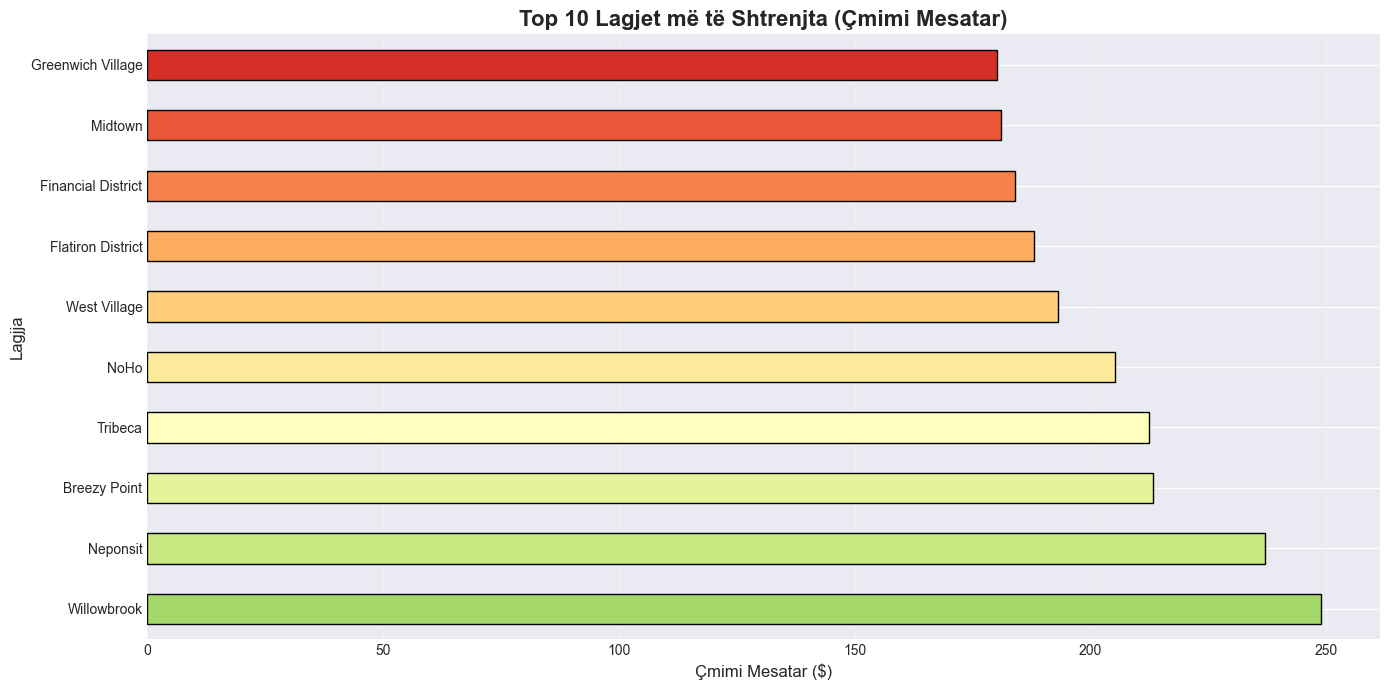


📊 TOP 10 LAGJET MË TË SHTRENJTA:

    1. Willowbrook                              $ 249.00
    2. Neponsit                                 $ 237.00
    3. Breezy Point                             $ 213.33
    4. Tribeca                                  $ 212.50
    5. NoHo                                     $ 205.29
    6. West Village                             $ 193.12
    7. Flatiron District                        $ 188.09
    8. Financial District                       $ 183.97
    9. Midtown                                  $ 181.08
   10. Greenwich Village                        $ 180.17


In [18]:
# Top 10 lagjet më të shtrenjta
top_neighbourhoods = (
    K.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14, 7))

colors_gradient = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(top_neighbourhoods)))
top_neighbourhoods.plot(kind="barh", color=colors_gradient, edgecolor='black')

plt.title("Top 10 Lagjet më të Shtrenjta (Çmimi Mesatar)", fontsize=16, fontweight='bold')
plt.xlabel("Çmimi Mesatar ($)", fontsize=12)
plt.ylabel("Lagjja", fontsize=12)
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 TOP 10 LAGJET MË TË SHTRENJTA:\n")
for i, (neighbourhood, price) in enumerate(top_neighbourhoods.items(), 1):
    print(f"   {i:2d}. {neighbourhood:<40} ${price:>7.2f}")

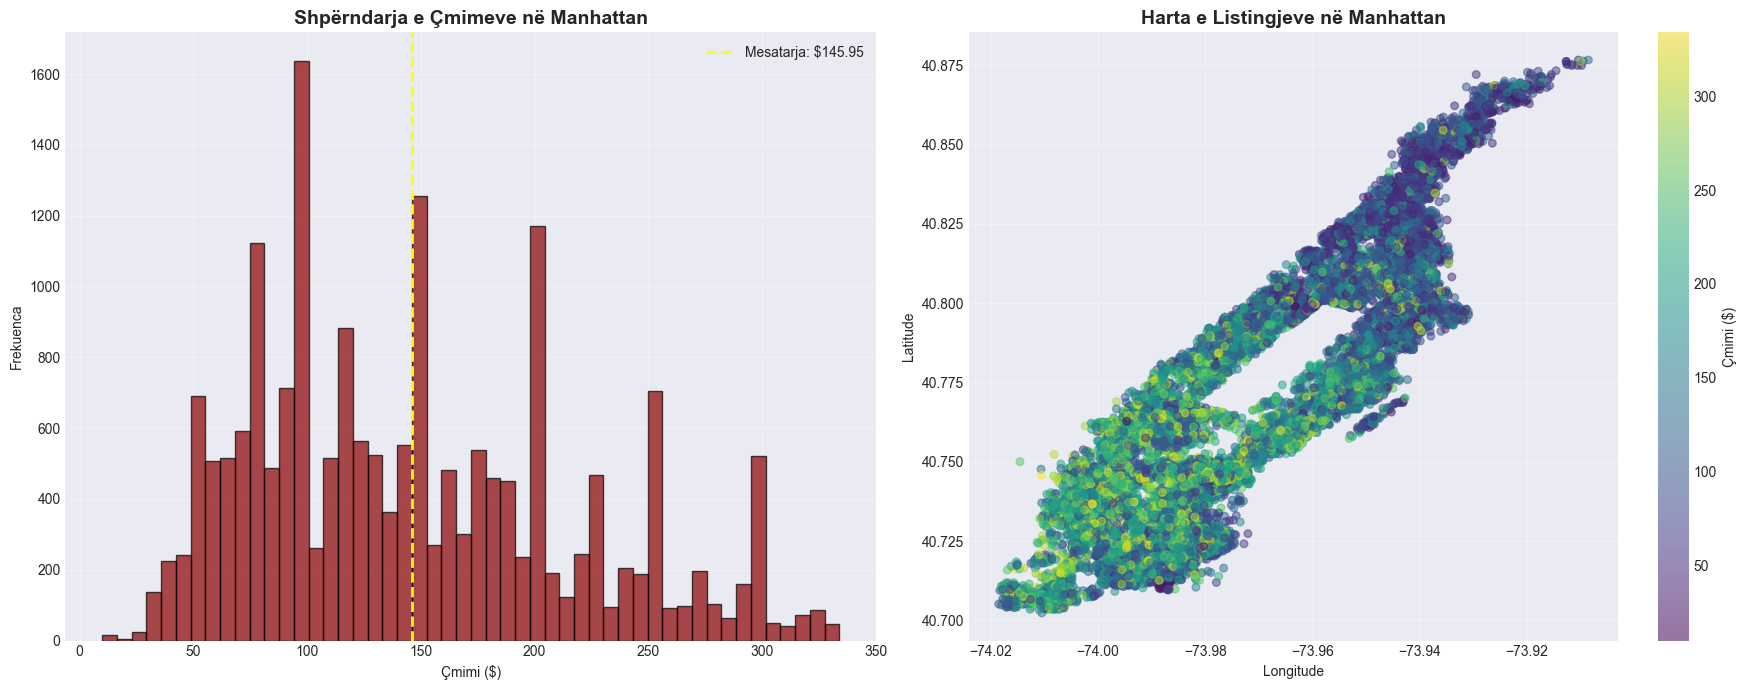


📊 STATISTIKA PËR MANHATTAN:
   Numri i listingjeve: 19,488
   Çmimi mesatar: $145.95
   Çmimi median: $135.00


In [19]:
# Analiza e Manhattan-it (zona më e shtrenjtë)
if 'neighbourhood_group' in K.columns:
    manhattan = K[K["neighbourhood_group"] == "Manhattan"]
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Histogram i çmimeve në Manhattan
    axes[0].hist(manhattan["price"], bins=50, color='darkred', edgecolor='black', alpha=0.7)
    axes[0].axvline(manhattan['price'].mean(), color='yellow', linestyle='--', linewidth=2, 
                    label=f'Mesatarja: ${manhattan["price"].mean():.2f}')
    axes[0].set_title("Shpërndarja e Çmimeve në Manhattan", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Çmimi ($)")
    axes[0].set_ylabel("Frekuenca")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Harta e Manhattan-it me çmime
    scatter = axes[1].scatter(
        manhattan["longitude"],
        manhattan["latitude"],
        c=manhattan["price"],
        cmap="viridis",
        alpha=0.5,
        s=30
    )
    
    plt.colorbar(scatter, ax=axes[1], label="Çmimi ($)")
    axes[1].set_title("Harta e Listingjeve në Manhattan", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 STATISTIKA PËR MANHATTAN:")
    print(f"   Numri i listingjeve: {len(manhattan):,}")
    print(f"   Çmimi mesatar: ${manhattan['price'].mean():.2f}")
    print(f"   Çmimi median: ${manhattan['price'].median():.2f}")

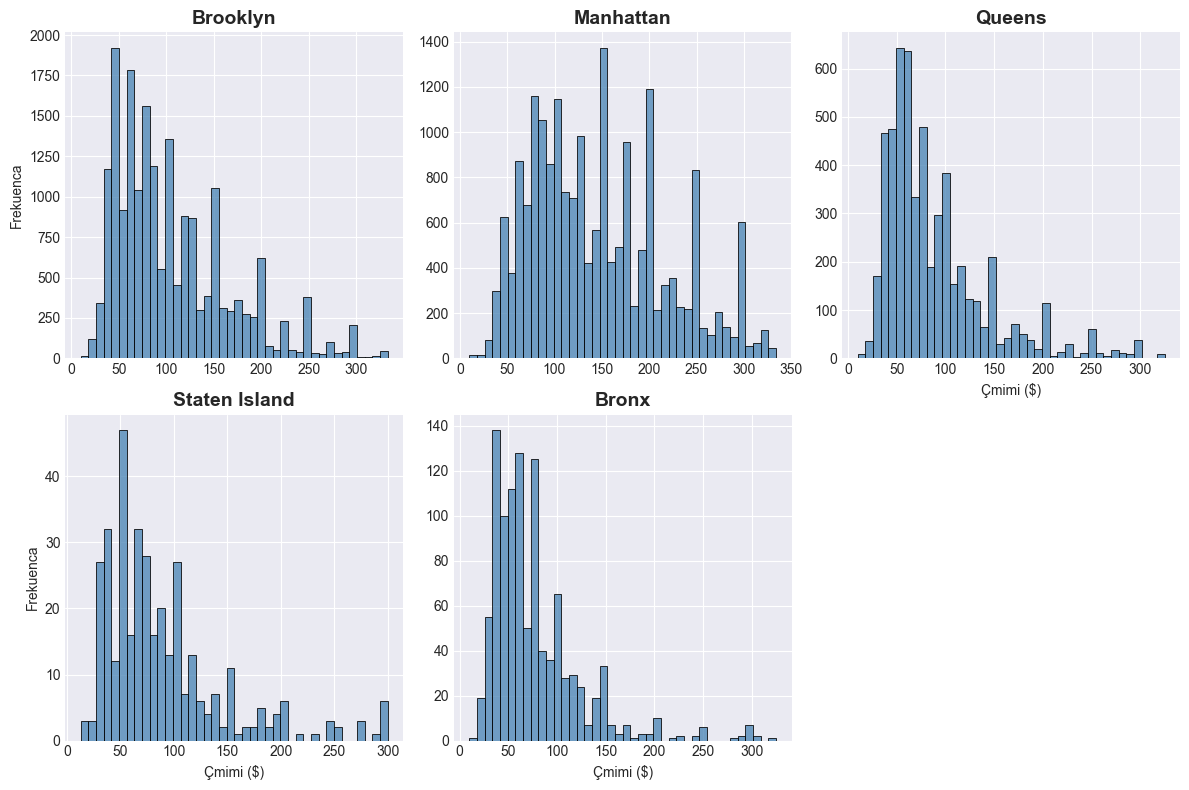

In [20]:
# FacetGrid - Çmimet sipas zonave
g = sns.FacetGrid(
    K,
    col="neighbourhood_group",
    col_wrap=3,
    height=4,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="price",
    bins=40,
    color='steelblue',
    edgecolor='black'
)

g.set_titles("{col_name}", size=14, weight='bold')
g.set_axis_labels("Çmimi ($)", "Frekuenca")
g.tight_layout()

plt.show()

---
## 7️⃣ ANALIZA E DISPONUESHMËRISË

📅 ANALIZA E DISPONUESHMËRISË SIPAS SEZONEVE

📊 Shpërndarja e Listingjeve sipas Kategorisë së Disponueshmërisë:

   E ulët (0-90)                  27,947 listingje ( 60.9%)
   Mesatare (91-180)               4,912 listingje ( 10.7%)
   E lartë (181-270)               4,124 listingje (  9.0%)
   Shumë e lartë (271-365)         8,893 listingje ( 19.4%)


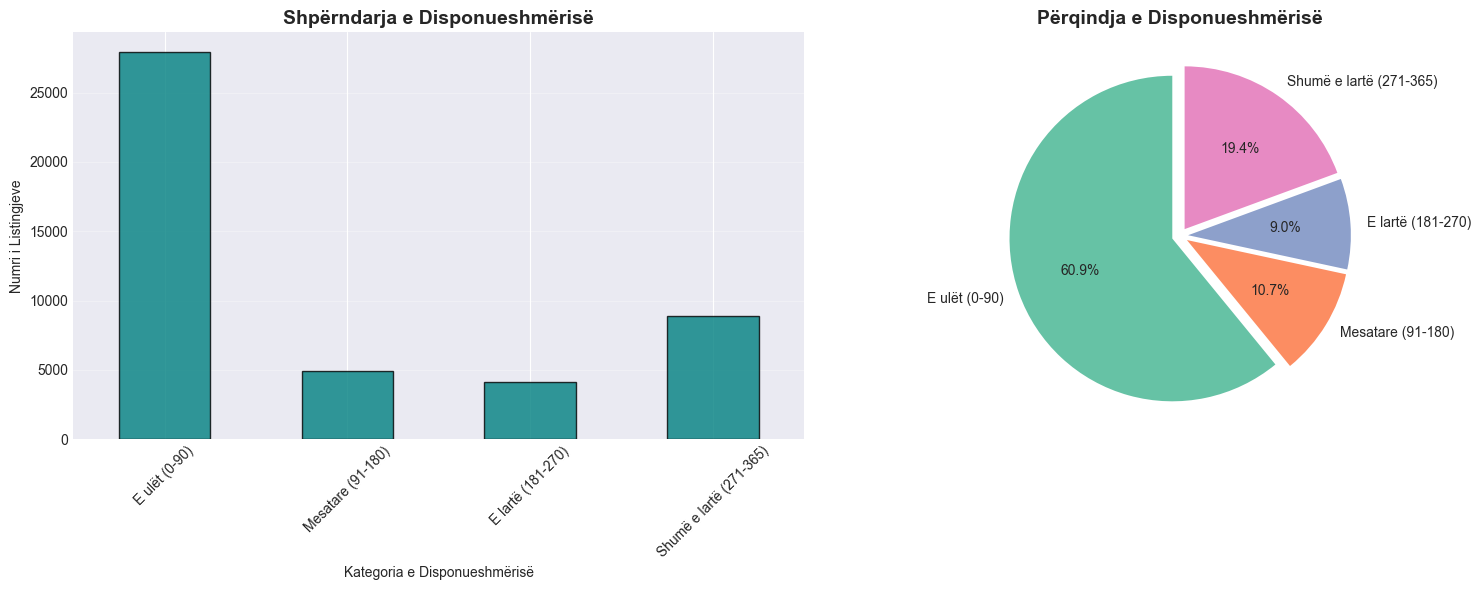

In [21]:
print("=" * 70)
print("📅 ANALIZA E DISPONUESHMËRISË SIPAS SEZONEVE")
print("=" * 70)

# Kategorizimi i disponueshmërisë në grupe
K['disponueshmeri_kategori'] = pd.cut(
    K['availability_365'],
    bins=[0, 90, 180, 270, 365],
    labels=['E ulët (0-90)', 'Mesatare (91-180)', 'E lartë (181-270)', 'Shumë e lartë (271-365)'],
    include_lowest=True
)

print("\n📊 Shpërndarja e Listingjeve sipas Kategorisë së Disponueshmërisë:\n")
disp_dist = K['disponueshmeri_kategori'].value_counts().sort_index()
for kat, count in disp_dist.items():
    pct = (count / len(K)) * 100
    print(f"   {kat:<30} {count:>6,} listingje ({pct:>5.1f}%)")

# Vizualizimi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
disp_dist.plot(kind='bar', ax=axes[0], color='teal', edgecolor='black', alpha=0.8)
axes[0].set_title("Shpërndarja e Disponueshmërisë", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Kategoria e Disponueshmërisë")
axes[0].set_ylabel("Numri i Listingjeve")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# Pie chart
axes[1].pie(
    disp_dist.values,
    labels=disp_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2'),
    explode=[0.05, 0.05, 0.05, 0.05]
)
axes[1].set_title("Përqindja e Disponueshmërisë", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


📊 DISPONUESHMËRIA SIPAS ZONËS:

                       mean  median     std
neighbourhood_group                        
Bronx                164.54   146.0  134.95
Brooklyn              98.49    26.0  125.41
Manhattan            105.93    29.0  130.39
Queens               143.05    95.0  135.08
Staten Island        199.89   219.0  131.04


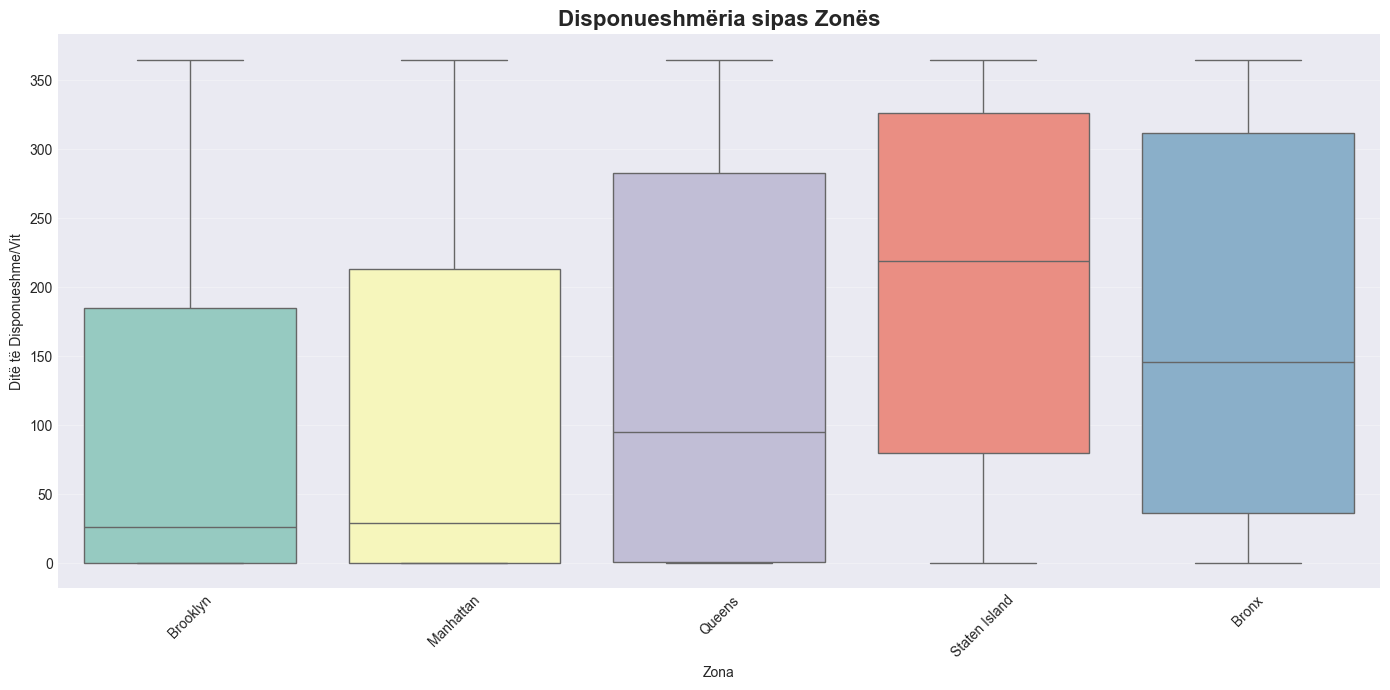


📊 DISPONUESHMËRIA SIPAS TIPIT TË DHOMËS:

                   mean  median     std
room_type                              
Entire home/apt  106.13    34.0  127.41
Private room     110.04    44.0  131.42
Shared room      162.75    90.0  151.58


In [22]:
# Analiza e disponueshmërisë sipas zonës dhe tipit
if 'neighbourhood_group' in K.columns:
    print("\n📊 DISPONUESHMËRIA SIPAS ZONËS:\n")
    zone_disp = K.groupby('neighbourhood_group')['availability_365'].agg(['mean', 'median', 'std']).round(2)
    print(zone_disp)
    
    # Boxplot
    plt.figure(figsize=(14, 7))
    sns.boxplot(x='neighbourhood_group', y='availability_365', data=K, palette='Set3')
    plt.title("Disponueshmëria sipas Zonës", fontsize=16, fontweight='bold')
    plt.xlabel("Zona")
    plt.ylabel("Ditë të Disponueshme/Vit")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print("\n📊 DISPONUESHMËRIA SIPAS TIPIT TË DHOMËS:\n")
room_disp = K.groupby('room_type')['availability_365'].agg(['mean', 'median', 'std']).round(2)
print(room_disp)

### 📊 INTERPRETIMI I GJETJEVE - Analiza e Disponueshmërisë

**1. Gjetja Kryesore: Disponueshmëri e Ulët Dominon**

- **60.9%** e listingjeve kanë disponueshmëri të ulët (0-90 ditë/vit)
- Kjo tregon një treg shumë të nxehtë me kërkesë të lartë
- Shumica e listingjeve janë të rezervuara ose jo-aktive për pjesën më të madhe të vitit

**2. Listingje Profesionale**

- Vetëm **19.4%** kanë disponueshmëri shumë të lartë (271-365 ditë)
- Këto janë kryesisht listingje profesionale/komerciale
- Host që operojnë si biznes i vërtetë Airbnb

**3. Implikime për Treg**

- Treg me konkurrencë të lartë
- Shumë host përdorin Airbnb si burim shtesë të ardhurash (jo kryesor)
- Mundësi për rritje për host profesionistë

---
## 8️⃣ ANALIZA E AKTIVITETIT TË LISTINGJEVE

In [24]:
print("=" * 70)
print("📅 ANALIZA E AKTIVITETIT TË LISTINGJEVE")
print("=" * 70)

# Kontrollojmë nëse kemi kolonën last_review
if 'last_review' in K.columns:
    # Konvertimi në datetime
    K['last_review'] = pd.to_datetime(K['last_review'], errors='coerce')
    
    # Data e fundit në dataset
    data_max = K['last_review'].max()
    print(f"\n📆 Data më e fundit e review në dataset: {data_max.strftime('%Y-%m-%d') if pd.notna(data_max) else 'N/A'}")
    
    # Shpërndarja e reviews sipas viteve
    print("\n📊 Shpërndarja e Reviews sipas Viteve:\n")
    K['review_year'] = K['last_review'].dt.year
    reviews_vit = K['review_year'].value_counts().sort_index().tail(10)
    for vit, count in reviews_vit.items():
        if pd.notna(vit):
            print(f"   {int(vit)}: {count:>6,} reviews")
    
    # Vizualizimi
    plt.figure(figsize=(14, 7))
    reviews_vit.plot(kind='bar', color='coral', edgecolor='black', alpha=0.8)
    plt.title("Numri i Reviews sipas Viteve", fontsize=16, fontweight='bold')
    plt.xlabel("Viti")
    plt.ylabel("Numri i Reviews")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

📅 ANALIZA E AKTIVITETIT TË LISTINGJEVE


📅 ANALIZA: LISTINGJE TË REJA VS TË VJETRA

📊 Shpërndarja e Listingjeve sipas 'Moshës':

   Shumë i ri (0-5 rev)           22,969 listingje ( 50.1%)
   I ri (6-20 rev)                10,182 listingje ( 22.2%)
   I establishuar (21-50 rev)      5,981 listingje ( 13.0%)
   Veteran (>50 rev)               6,744 listingje ( 14.7%)

📊 ÇMIMET SIPAS MOSHËS SË LISTINGUT:

                              mean  median    std
moshë_listingu                                   
Shumë i ri (0-5 rev)        121.90   100.0  70.98
I ri (6-20 rev)             119.98   100.0  66.88
I establishuar (21-50 rev)  116.04    99.0  63.96
Veteran (>50 rev)           117.08   100.0  63.26


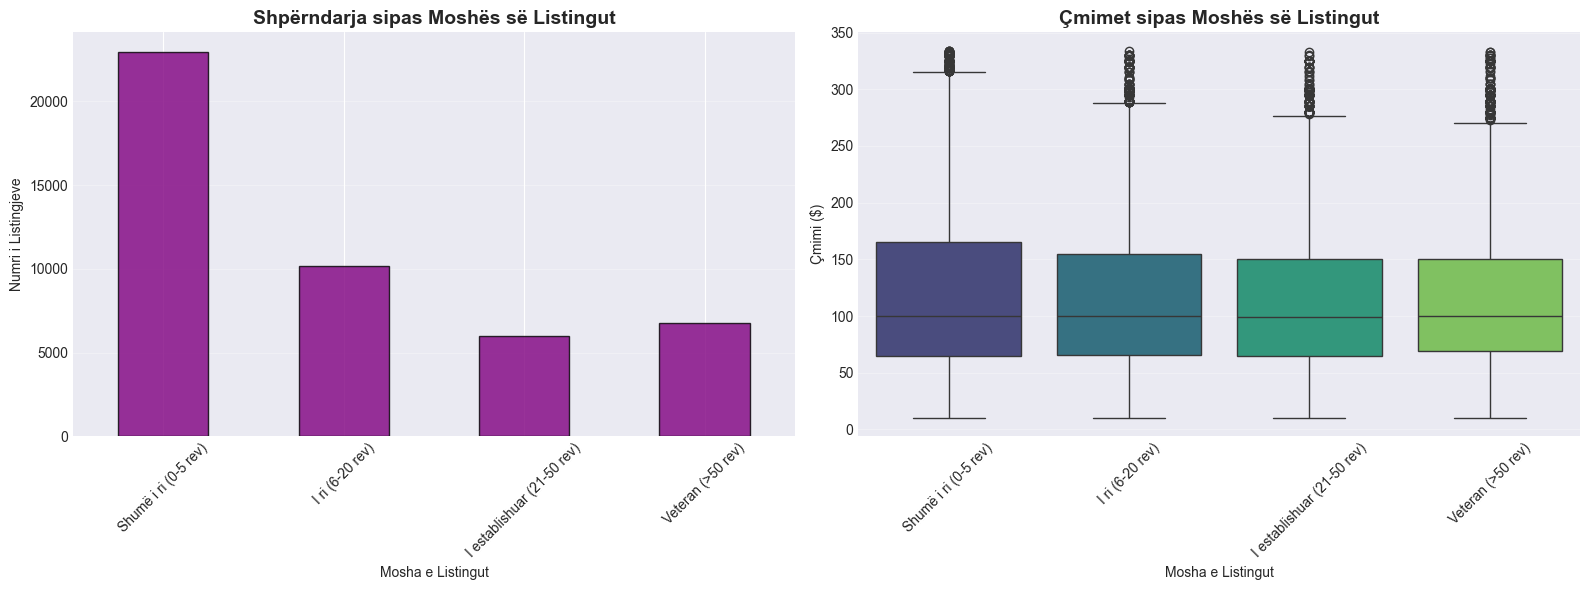

In [25]:
# Analiza e listingjeve të reja vs të vjetra
print("=" * 70)
print("📅 ANALIZA: LISTINGJE TË REJA VS TË VJETRA")
print("=" * 70)

# Kategorizimi bazuar në numrin e reviews
K['moshë_listingu'] = pd.cut(
    K['number_of_reviews'],
    bins=[0, 5, 20, 50, np.inf],
    labels=['Shumë i ri (0-5 rev)', 'I ri (6-20 rev)', 'I establishuar (21-50 rev)', 'Veteran (>50 rev)'],
    include_lowest=True
)

print("\n📊 Shpërndarja e Listingjeve sipas 'Moshës':\n")
moshe_dist = K['moshë_listingu'].value_counts().sort_index()
for kat, count in moshe_dist.items():
    pct = (count / len(K)) * 100
    print(f"   {kat:<30} {count:>6,} listingje ({pct:>5.1f}%)")

# Krahasimi i çmimeve
print("\n📊 ÇMIMET SIPAS MOSHËS SË LISTINGUT:\n")
moshe_price = K.groupby('moshë_listingu')['price'].agg(['mean', 'median', 'std']).round(2)
print(moshe_price)

# Vizualizimi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
moshe_dist.plot(kind='bar', ax=axes[0], color='purple', edgecolor='black', alpha=0.8)
axes[0].set_title("Shpërndarja sipas Moshës së Listingut", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Mosha e Listingut")
axes[0].set_ylabel("Numri i Listingjeve")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')

# Boxplot për çmime
sns.boxplot(x='moshë_listingu', y='price', data=K, ax=axes[1], palette='viridis')
axes[1].set_title("Çmimet sipas Moshës së Listingut", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Mosha e Listingut")
axes[1].set_ylabel("Çmimi ($)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 📊 INTERPRETIMI I GJETJEVE - Listingje të Reja vs të Vjetra

**1. Dominimi i Listingjeve të Reja**

- **50.1%** e listingjeve janë shumë të reja (0-5 reviews)
- Kjo tregon një treg në rritje të shpejtë
- Influx masiv i host-eve të rinj që hyjnë në treg

**2. Skenarit e Mundshëm**

- **Skenar 1:** Rritje e shpejtë e tregut (2018-2019 para COVID)
- **Skenar 2:** Churn i lartë - listingje që largohen shpejt nga tregu
- **Skenar 3:** Dataset i mbledhur në një periudhë të veçantë

**3. Implikime**

- Konkurrencë e lartë për listingje të reja
- Cilësi e panjohur për shumicën
- Mundësi për zgjedhje të gjerë për konsumatorët

---
## 9️⃣ ANALIZA E HOST-EVE

👥 ANALIZA E HOST-EVE - SUPERHOSTS VS HOSTS TË RREGULLT

📊 Shpërndarja e Host-eve sipas Numrit të Listingjeve:

   Single (1 listing)        30,280 listingje ( 66.0%) | 30,280 host | Çmim mesatar: $125.44
   Small (2-5)               11,245 listingje ( 24.5%) | 4,740 host | Çmim mesatar: $101.56
   Medium (6-10)              1,731 listingje (  3.8%) |   246 host | Çmim mesatar: $ 91.49
   Large (11-50)              1,460 listingje (  3.2%) |    79 host | Çmim mesatar: $124.57
   Enterprise (>50)           1,160 listingje (  2.5%) |    11 host | Çmim mesatar: $193.50


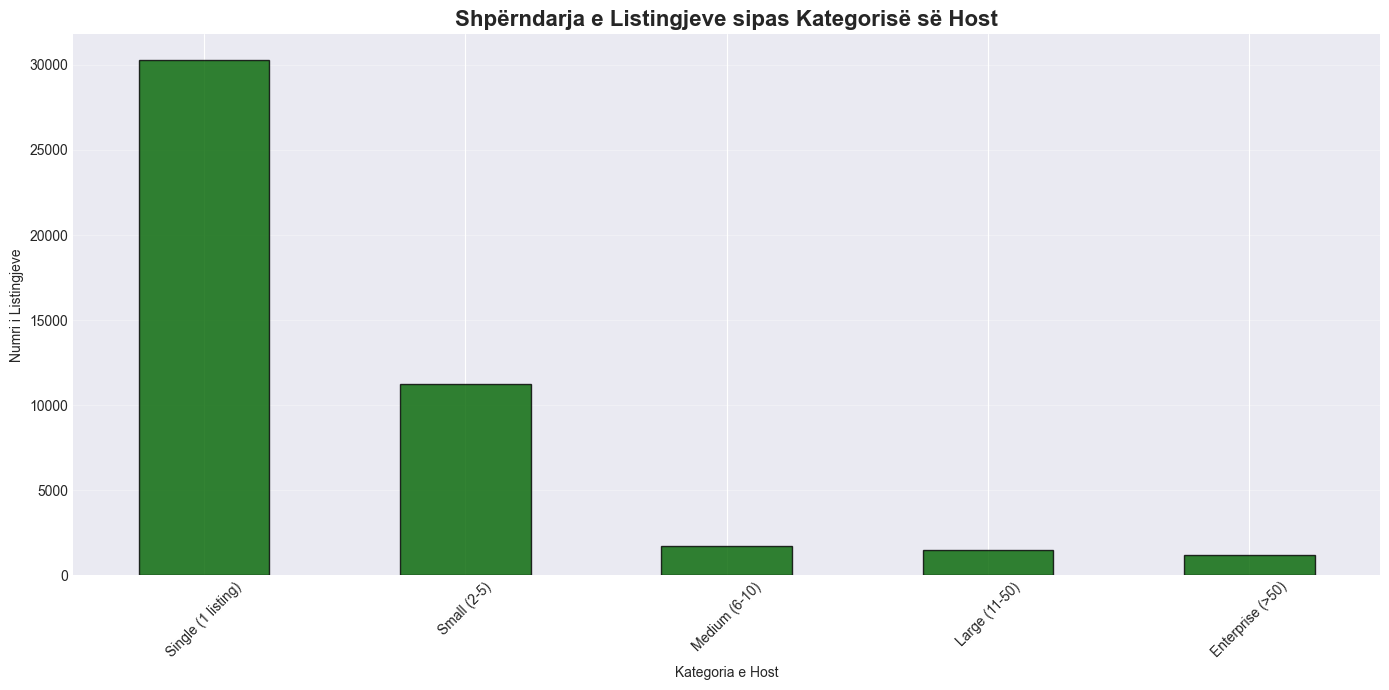

In [26]:
print("=" * 70)
print("👥 ANALIZA E HOST-EVE - SUPERHOSTS VS HOSTS TË RREGULLT")
print("=" * 70)

# Kategorizimi i host-eve sipas numrit të listingjeve
K['host_kategori'] = pd.cut(
    K['calculated_host_listings_count'],
    bins=[0, 1, 5, 10, 50, np.inf],
    labels=['Single (1 listing)', 'Small (2-5)', 'Medium (6-10)', 'Large (11-50)', 'Enterprise (>50)'],
    include_lowest=True
)

print("\n📊 Shpërndarja e Host-eve sipas Numrit të Listingjeve:\n")
host_dist = K['host_kategori'].value_counts().sort_index()
total_listings = len(K)

for kat, count in host_dist.items():
    pct = (count / total_listings) * 100
    unique_hosts = K[K['host_kategori'] == kat]['host_id'].nunique()
    avg_price = K[K['host_kategori'] == kat]['price'].mean()
    print(f"   {kat:<25} {count:>6,} listingje ({pct:>5.1f}%) | {unique_hosts:>5,} host | Çmim mesatar: ${avg_price:>6.2f}")

# Vizualizimi
plt.figure(figsize=(14, 7))
host_dist.plot(kind='bar', color='darkgreen', edgecolor='black', alpha=0.8)
plt.title("Shpërndarja e Listingjeve sipas Kategorisë së Host", fontsize=16, fontweight='bold')
plt.xlabel("Kategoria e Host")
plt.ylabel("Numri i Listingjeve")
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

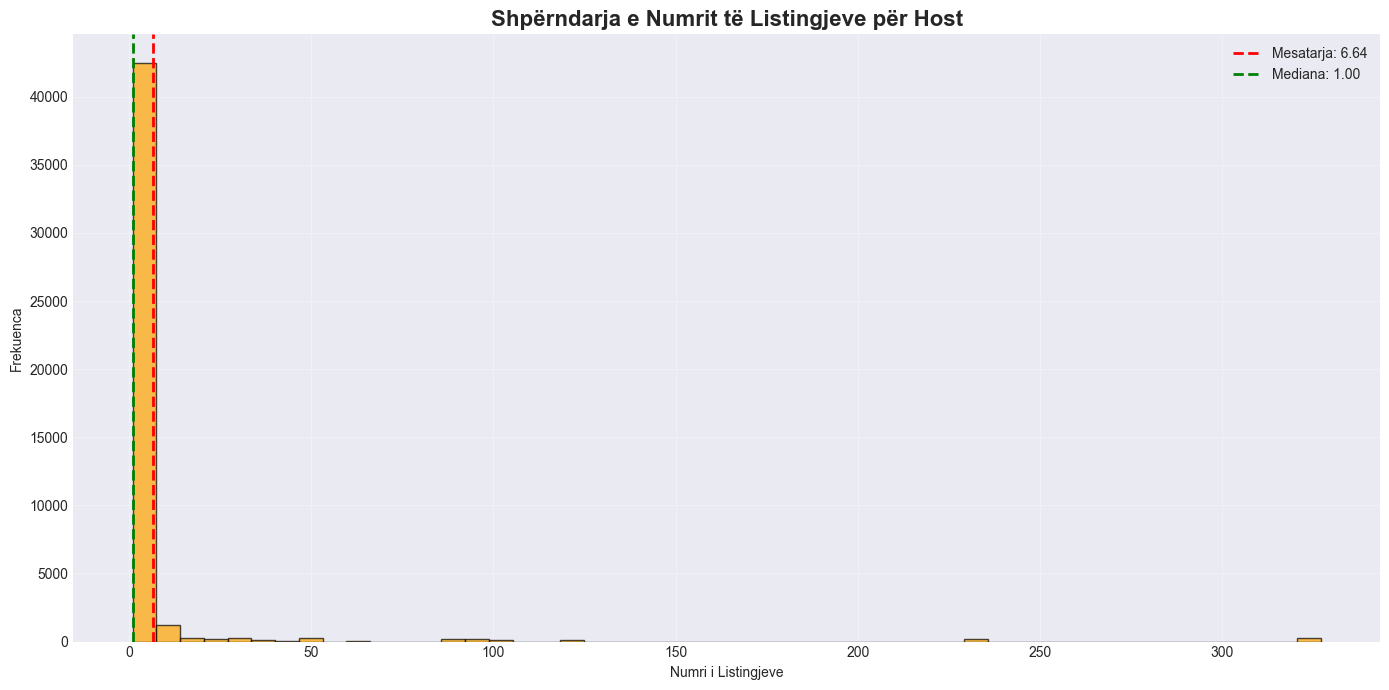


📊 STATISTIKA E HOST-EVE:
   Numri mesatar i listingjeve për host: 6.64
   Numri median i listingjeve për host: 1.00
   Maksimumi i listingjeve nga një host: 327


In [27]:
# Histogram i listingjeve për host
plt.figure(figsize=(14, 7))

plt.hist(
    K["calculated_host_listings_count"],
    bins=50,
    color='orange',
    edgecolor='black',
    alpha=0.7
)

plt.title("Shpërndarja e Numrit të Listingjeve për Host", fontsize=16, fontweight='bold')
plt.xlabel("Numri i Listingjeve")
plt.ylabel("Frekuenca")
plt.grid(alpha=0.3)

# Statistika
mean_listings = K['calculated_host_listings_count'].mean()
median_listings = K['calculated_host_listings_count'].median()
plt.axvline(mean_listings, color='red', linestyle='--', linewidth=2, label=f'Mesatarja: {mean_listings:.2f}')
plt.axvline(median_listings, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_listings:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n📊 STATISTIKA E HOST-EVE:")
print(f"   Numri mesatar i listingjeve për host: {mean_listings:.2f}")
print(f"   Numri median i listingjeve për host: {median_listings:.2f}")
print(f"   Maksimumi i listingjeve nga një host: {K['calculated_host_listings_count'].max():.0f}")

In [28]:
# Analiza e impaktit të numrit të listingjeve në çmim dhe reviews
print("=" * 70)
print("📊 IMPAKTI I NUMRIT TË LISTINGJEVE NË ÇMIM DHE REVIEWS")
print("=" * 70)

print("\n📋 Statistika Detajuara sipas Kategorisë së Host:\n")
host_impact = K.groupby('host_kategori').agg(
    Numri_Listingjeve=('id', 'count'),
    Cmimi_Mesatar=('price', 'mean'),
    Cmimi_Median=('price', 'median'),
    Reviews_Mesatar=('number_of_reviews', 'mean'),
    Reviews_Median=('number_of_reviews', 'median'),
    Reviews_per_Month=('reviews_per_month', 'mean'),
    Disponueshmeri=('availability_365', 'mean')
).round(2)

print(host_impact.to_string())

# Korrelacioni
if 'calculated_host_listings_count' in K.columns:
    print("\n📊 Korrelacioni: Numri i Listingjeve vs Metrика të Tjera:\n")
    correlations = K[['calculated_host_listings_count', 'price', 'number_of_reviews', 'availability_365']].corr()['calculated_host_listings_count'].sort_values(ascending=False)
    for var, corr in correlations.items():
        if var != 'calculated_host_listings_count':
            print(f"   {var:<35} {corr:>6.3f}")

📊 IMPAKTI I NUMRIT TË LISTINGJEVE NË ÇMIM DHE REVIEWS

📋 Statistika Detajuara sipas Kategorisë së Host:

                    Numri_Listingjeve  Cmimi_Mesatar  Cmimi_Median  Reviews_Mesatar  Reviews_Median  Reviews_per_Month  Disponueshmeri
host_kategori                                                                                                                         
Single (1 listing)              30280         125.44         110.0            20.88             4.0               1.11           75.16
Small (2-5)                     11245         101.56          81.0            36.16            13.0               1.68          145.84
Medium (6-10)                    1731          91.49          70.0            22.87             7.0               1.69          224.68
Large (11-50)                    1460         124.57         119.0            12.18             2.0               0.80          265.04
Enterprise (>50)                 1160         193.50         200.0             1.87  

📊 KONCENTRIMI I TREGUT - MARKET CONCENTRATION ANALYSIS

📊 Koncentrimi i Tregut - Top Hosts:

Top % Hosts     Numri Hosts     Listingje       % e Tregut      Mes List/Host  
---------------------------------------------------------------------------
Top 1%          353             4,467           9.74            12.65          
Top 5%          1,767           9,196           20.05           5.20           
Top 10%         3,535           12,732          27.75           3.60           
Top 20%         7,071           17,591          38.34           2.49           
Top 50%         17,678          28,198          61.47           1.60           


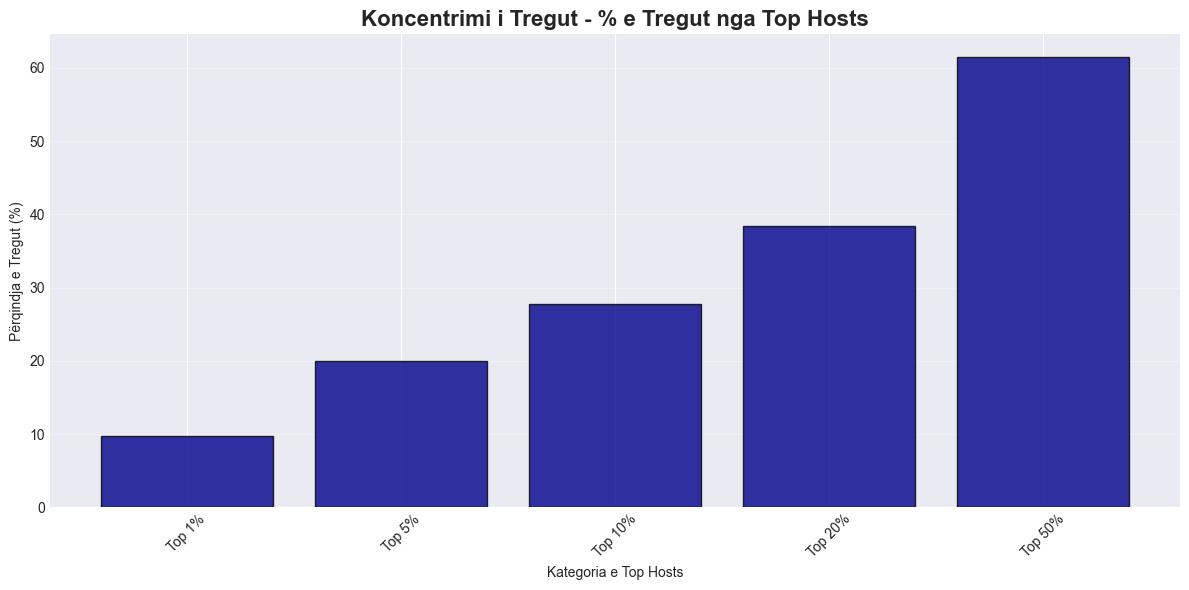


📊 INTERPRETIMI:
• Nëse top hosts kontrollojnë një përqindje të madhe, tregu është i koncentruar
• Nëse shpërndarja është e balancuar, tregu është më kompetitiv
• Concentration i lartë tregon dominim nga operatorë të mëdhenj


In [29]:
# Analiza e koncentrimit të tregut
print("=" * 70)
print("📊 KONCENTRIMI I TREGUT - MARKET CONCENTRATION ANALYSIS")
print("=" * 70)

# Llogaritja e përqindjes së listingjeve të kontrolluara nga top hosts
host_listings = K.groupby('host_id').size().sort_values(ascending=False)

total_hosts = len(host_listings)
total_listings = len(K)

# Top 1%, 5%, 10%, 20%, 50% të host-eve
percentiles = [1, 5, 10, 20, 50]

print("\n📊 Koncentrimi i Tregut - Top Hosts:\n")
print(f"{'Top % Hosts':<15} {'Numri Hosts':<15} {'Listingje':<15} {'% e Tregut':<15} {'Mes List/Host':<15}")
print("-" * 75)

concentration_data = []
for pct in percentiles:
    n_hosts = max(1, int(total_hosts * pct / 100))
    top_n_listings = host_listings.head(n_hosts).sum()
    market_share = (top_n_listings / total_listings) * 100
    avg_per_host = top_n_listings / n_hosts
    
    print(f"{f'Top {pct}%':<15} {n_hosts:<15,} {top_n_listings:<15,} {market_share:<15.2f} {avg_per_host:<15.2f}")
    concentration_data.append({'Percentile': f'Top {pct}%', 'Market Share': market_share})

# Vizualizimi
concentration_df = pd.DataFrame(concentration_data)
plt.figure(figsize=(12, 6))
plt.bar(concentration_df['Percentile'], concentration_df['Market Share'], color='darkblue', edgecolor='black', alpha=0.8)
plt.title("Koncentrimi i Tregut - % e Tregut nga Top Hosts", fontsize=16, fontweight='bold')
plt.xlabel("Kategoria e Top Hosts")
plt.ylabel("Përqindja e Tregut (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("""\n📊 INTERPRETIMI:
• Nëse top hosts kontrollojnë një përqindje të madhe, tregu është i koncentruar
• Nëse shpërndarja është e balancuar, tregu është më kompetitiv
• Concentration i lartë tregon dominim nga operatorë të mëdhenj""")

---
## 🔟 ANALIZA E CLUSTERAVE (nëse ka të dhëna cluster)

In [30]:
# Vizualizimi i clusterave (nëse ekziston kolona 'cluster')
if 'cluster' in K.columns:
    plt.figure(figsize=(14, 10))
    
    scatter = plt.scatter(
        K["longitude"],
        K["latitude"],
        c=K["cluster"],
        cmap="tab10",
        alpha=0.5,
        s=30
    )
    
    plt.colorbar(scatter, label="Cluster ID")
    plt.title("Harta e Listingjeve të Clusterizuara", fontsize=16, fontweight='bold')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Statistika për cluster
    print("\n📊 STATISTIKA SIPAS CLUSTER:\n")
    cluster_stats = K.groupby('cluster').agg(
        Numri=('id', 'count'),
        Cmimi_Mes=('price', 'mean'),
        Reviews_Mes=('number_of_reviews', 'mean'),
        Disp_Mes=('availability_365', 'mean')
    ).round(2)
    print(cluster_stats)
else:
    print("\n⚠️ Kolona 'cluster' nuk ekziston në dataset.")


⚠️ Kolona 'cluster' nuk ekziston në dataset.


---
## 📋 PËRFUNDIME DHE GJETJE KRYESORE

### 🎯 Gjetjet Kryesore nga Analiza

#### 1️⃣ **Dendësia Gjeografike**
- Manhattan dhe Brooklyn kanë dendësinë më të lartë të listingjeve
- Zonat periferike kanë më pak listingje por mund të ofrojnë mundësi

#### 2️⃣ **Çmimet**
- Manhattan ka çmimet mesatare më të larta
- Ekziston shtrembërim i fortë djathtas në shpërndarjen e çmimeve
- Shumica e listingjeve janë në segmentin e çmimeve të ulëta deri mesatare

#### 3️⃣ **Tipet e Dhomave**
- "Entire home/apt" është tipi më i zakonshëm
- "Private room" ka çmime më të ulëta
- "Shared room" është më pak e zakonshme

#### 4️⃣ **Disponueshmëria**
- 60.9% e listingjeve kanë disponueshmëri të ulët (0-90 ditë)
- Vetëm 19.4% janë të disponueshme për pjesën më të madhe të vitit
- Kjo tregon një treg me kërkesë të lartë

#### 5️⃣ **Aktiviteti**
- 50.1% e listingjeve janë shumë të reja (0-5 reviews)
- Tregon një treg në rritje të shpejtë ose churn të lartë
- Listingjet e vjetra (veteran) përfaqësojnë vetëm 14.7%

#### 6️⃣ **Host-et**
- Shumica e host-eve kanë vetëm 1 listing (single hosts)
- Ekzistojnë host me shumë listingje që kontrollojnë një pjesë të tregut
- Tregu ka një shkallë të caktuar koncentrацioni

### 💡 Rekomandime

1. **Për Host të Rinj:**
   - Fokusohuni në çmime konkurruese
   - Investoni në reviews të hershme cilësore
   - Zgjidhni zonat me konkurrencë më të ulët

2. **Për Investitorë:**
   - Shqyrtoni zonat jashtë Manhattan për ROI më të mirë
   - Konsideroni disponueshmërinë e lartë për të maksimizuar të ardhurat

3. **Për Analiza të Mëtejshme:**
   - Analiza kohore më e detajuar
   - Modeling prediktiv për çmime
   - Analiza e sentimentit nga reviews

---

**📊 Analiza u përfundua me sukses!**

**Data:** 2024  
**Dataset:** NYC Airbnb Open Data 2019  
**Mjet:** Python (Pandas, Matplotlib, Seaborn)